# 공통 시점 벤치마크와 물리 위반

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT/'configs/base_config.yaml').exists(): ROOT = ROOT.parent
manifest = json.loads((ROOT/'reports/corrected_run_manifest.json').read_text(encoding='utf-8'))
run = ROOT/'models/runs'/manifest['run_id']
print(manifest['run_id'], '|', manifest['test_role'])

corrected_v3_20261004T005217+0900 | development_benchmark_previously_consulted


모든 모델은 horizon별 공통 target_time/issue_time에서 비교합니다. 오차는 clipped 출력, 범위 위반은 raw 출력입니다. LightGBM은 시퀀스 모델보다 긴 lag 및 달력 특징을 사용합니다. 단일 seed 결과입니다.

In [2]:
b=pd.read_csv(ROOT/'reports/tables/comprehensive_extended_metric_matrix.csv')
display(b[['model','horizon','count','mae','rmse','bound_violation_pct']])
assert (b.groupby('horizon')['count'].nunique()==1).all()

,model,horizon,count,mae,rmse,bound_violation_pct
0,EMFN (Proposed),+1h,8736,0.8018,1.2758,0.0000
1,DLinear (+Weather),+1h,8736,0.8364,1.2996,13.8393
2,LSTM (+Weather),+1h,8736,0.7866,1.2636,4.1667
3,GRU (+Weather),+1h,8736,0.8153,1.3062,0.0000
4,CNN-LSTM (+Weather),+1h,8736,0.8507,1.3680,11.4927
5,TCN (+Weather),+1h,8736,0.8279,1.3076,3.6401
6,Transformer (+Weather),+1h,8736,0.8499,1.3601,10.1763
7,LightGBM (+Weather),+1h,8736,0.7388,1.1743,2.1406
8,Naive Persistence,+1h,8736,0.8602,1.4337,0.0000
9,24h Diurnal Persistence,+1h,8736,3.5634,5.4338,0.0000


,model,horizon_hours,total_test_hours,available_count,common_count,excluded_from_common
0,EMFN (Proposed),1,8760,8736,8736,24
1,DLinear (+Weather),1,8760,8736,8736,24
2,LSTM (+Weather),1,8760,8736,8736,24
3,GRU (+Weather),1,8760,8736,8736,24
4,CNN-LSTM (+Weather),1,8760,8736,8736,24
5,TCN (+Weather),1,8760,8736,8736,24
6,Transformer (+Weather),1,8760,8736,8736,24
7,LightGBM (+Weather),1,8760,8759,8736,24
8,Naive Persistence,1,8760,8759,8736,24
9,24h Diurnal Persistence,1,8760,8736,8736,24


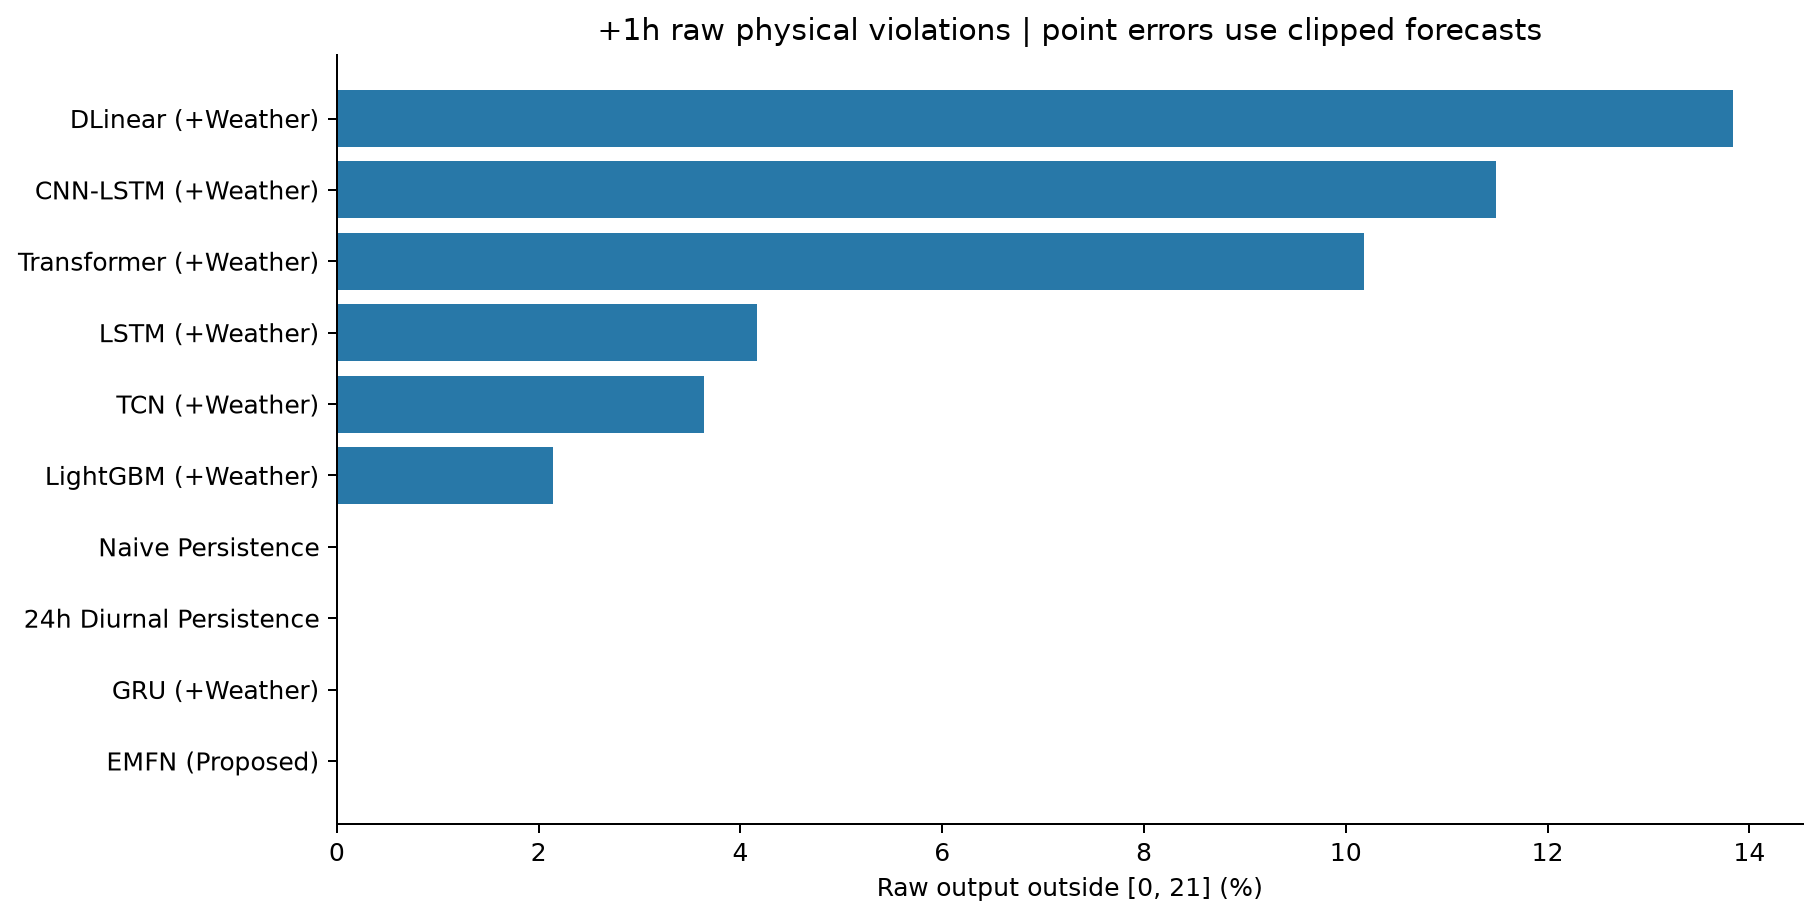

In [3]:
display(pd.read_csv(ROOT/'reports/tables/benchmark_coverage.csv'))
display(Image(filename=str(ROOT/'reports/figures/raw_boundary_violations.png')))

## ARIMA 및 확률 LightGBM 확장 비교

기존 10개 모델 결과는 위에 보존했습니다. 아래는 확장 당시 본문 후보 비교 모델 5개와 EMFN입니다. MAE는 확률 모델의 중앙값, RMSE는 평균 기준입니다. 기존 위 표의 평균 MAE와 구분합니다. 신규 모델은 검증 CRPS로 선택했으며, 기존 EMFN/CNN-LSTM은 기존 검증 손실로 선택한 체크포인트를 재사용했습니다. 2025 개발 벤치마크·단일 seed 결과이며 통계적 유의성을 검증하지 않았습니다. 상세 분포 구성과 재현 명령은 reports/probabilistic_baselines.md를 참고하십시오.

,model,horizon,count,crps,zero_brier,rmse,mae,zero_auprc
0,EMFN (Proposed),+1h,8736,0.577478,0.071623,1.2758,0.7993,0.758931
1,CNN-LSTM (+Weather),+1h,8736,0.850686,NaN,1.3680,0.8507,NaN
2,ARIMA,+1h,8736,0.668857,0.101655,1.4261,0.8369,0.621272
3,LightGBM (24h matched),+1h,8736,0.820885,NaN,1.2867,0.8209,NaN
4,Quantile LightGBM (24h matched),+1h,8736,0.596026,0.117936,1.3950,0.8051,0.598647
5,Hurdle Quantile LightGBM (24h matched),+1h,8736,0.581340,0.064250,1.3489,0.7921,0.758524
6,EMFN (Proposed),+3h,8734,1.077254,0.094743,2.3828,1.5099,0.559593
7,CNN-LSTM (+Weather),+3h,8734,1.463996,NaN,2.3401,1.4640,NaN
8,ARIMA,+3h,8734,1.336205,0.127608,2.8134,1.7853,0.475515
9,LightGBM (24h matched),+3h,8734,1.587343,NaN,2.3372,1.5873,NaN


,model,crps,zero_brier,rmse,mae,zero_auprc
0,EMFN (Proposed),1.475212,0.110742,3.126733,2.069517,0.448648
1,ARIMA,1.696725,0.123586,3.372917,2.387467,0.399585
2,CNN-LSTM (+Weather),2.043826,NaN,3.204017,2.043833,NaN
3,LightGBM (24h matched),2.208557,NaN,3.072100,2.208550,NaN
4,Quantile LightGBM (24h matched),1.468862,0.126175,3.144033,2.016767,0.385162
5,Hurdle Quantile LightGBM (24h matched),1.460748,0.107090,3.114000,2.015600,0.448909


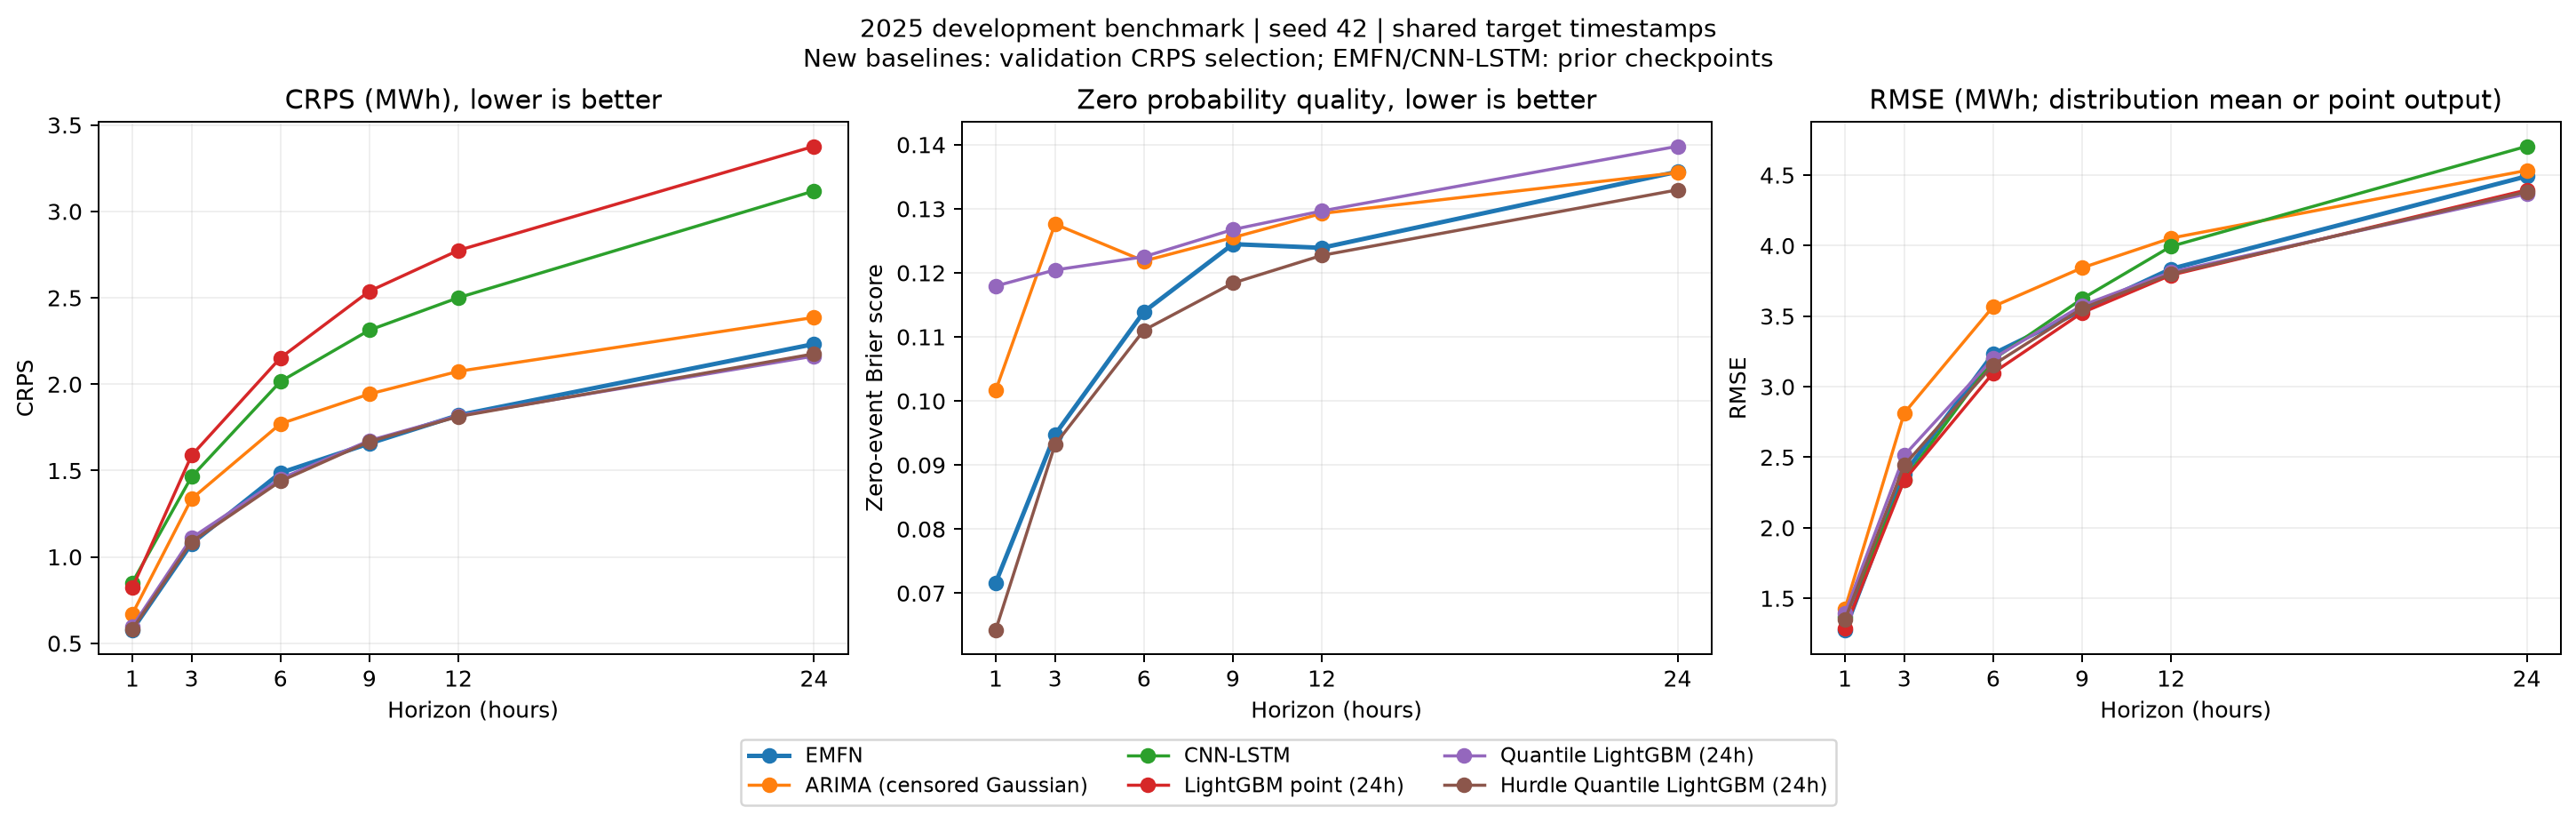

Verified extension: probabilistic_extension_20261004T121114+0900


In [4]:
extension = json.loads((ROOT/'reports/probabilistic_run_manifest.json').read_text(encoding='utf-8'))
verification = json.loads((ROOT/'reports/probabilistic_artifact_validation.json').read_text(encoding='utf-8'))
assert extension['status'] == 'complete' and verification['status'] == 'passed'
assert extension['run_id'] == verification['run_id']
paper = pd.read_csv(ROOT/'reports/tables/paper_five_comparators.csv')
assert len(paper) == 36 and paper.groupby('horizon')['count'].nunique().eq(1).all()
display(paper[['model','horizon','count','crps','zero_brier','rmse','mae','zero_auprc']])
display(pd.read_csv(ROOT/'reports/tables/paper_five_comparators_horizon_mean.csv'))
display(Image(filename=str(ROOT/'reports/figures/probabilistic_baseline_comparison.png')))
print('Verified extension:', extension['run_id'])

## 검증 CRPS 선택 통일 및 3개 시드

아래는 완료된 6개 모델 실험의 전체 기록입니다. 현재 본문/보조 표 배치는 마지막 절을 참고하십시오. 이전 단일 시드 표는 위에 보존했습니다. 시드는 42·2026·3407이며 ARIMA는 결정론 적합 1회입니다. 신경망 선택·조기 종료와 EMFN 스케줄러는 검증 CRPS 기준입니다. 시드 SD와 시간 블록 95% 구간은 서로 다른 변동을 나타냅니다. 이 결과는 2025 개발 벤치마크의 탐색적 비교입니다. 상세 해석은 reports/multiseed_crps_results.md를 참고하십시오.

,model,n_fits_per_horizon,crps_mean,crps_sd,zero_brier_mean,zero_brier_sd,rmse_mean,rmse_sd,mae_mean,mae_sd,zero_auprc_mean,zero_auprc_sd
0,EMFN (Proposed),3,1.464178,0.012574,0.111347,0.000527,3.104061,0.022487,2.046667,0.019539,0.444717,0.002903
1,ARIMA,1,1.696725,NaN,0.123586,NaN,3.372917,NaN,2.387467,NaN,0.399585,NaN
2,CNN-LSTM (+Weather),3,2.089578,0.026746,NaN,NaN,3.294472,0.061653,2.089583,0.026753,NaN,NaN
3,LightGBM (24h matched),3,2.208557,0.000000,NaN,NaN,3.072100,0.000000,2.208550,0.000000,NaN,NaN
4,Quantile LightGBM (24h matched),3,1.468862,0.000000,0.126175,0.000000,3.144033,0.000000,2.016767,0.000000,0.385162,0.000000
5,Hurdle Quantile LightGBM (24h matched),3,1.460748,0.000000,0.107090,0.000000,3.114000,0.000000,2.015600,0.000000,0.448909,0.000000


,split,model,horizon_hours,n_fits,crps_mean,crps_sd,zero_brier_mean,zero_brier_sd,rmse_mean,rmse_sd,mae_mean,mae_sd,zero_auprc_mean,zero_auprc_sd
1,test,ARIMA,1,1,0.668857,NaN,0.101655,NaN,1.426100,NaN,0.836900,NaN,0.621272,NaN
3,test,ARIMA,3,1,1.336205,NaN,0.127608,NaN,2.813400,NaN,1.785300,NaN,0.475515,NaN
5,test,ARIMA,6,1,1.770985,NaN,0.121843,NaN,3.568300,NaN,2.460800,NaN,0.410169,NaN
7,test,ARIMA,9,1,1.943295,NaN,0.125496,NaN,3.842900,NaN,2.757200,NaN,0.345465,NaN
9,test,ARIMA,12,1,2.074488,NaN,0.129268,NaN,4.053400,NaN,2.986400,NaN,0.316654,NaN
11,test,ARIMA,24,1,2.386520,NaN,0.135646,NaN,4.533400,NaN,3.498200,NaN,0.228436,NaN
13,test,EMFN (Proposed),1,3,0.580223,5.758518e-03,0.069339,1.659979e-03,1.287867,1.550043e-02,0.800300,0.009938,0.751612,2.810994e-03
15,test,CNN-LSTM (+Weather),1,3,0.856458,2.619168e-02,NaN,NaN,1.374067,3.809650e-02,0.856467,0.026212,NaN,NaN
17,test,LightGBM (24h matched),1,3,0.820885,0.000000e+00,NaN,NaN,1.286700,0.000000e+00,0.820900,0.000000,NaN,NaN
19,test,Quantile LightGBM (24h matched),1,3,0.596026,0.000000e+00,0.117936,0.000000e+00,1.395000,2.719480e-16,0.805100,0.000000,0.598647,0.000000e+00


,model,horizon_hours,metric,difference,lower_95,upper_95,block_hours,repetitions,count
13,Hurdle Quantile LightGBM (24h matched),1,crps,-0.001117,-0.013499,0.011048,168,2000,8736
15,Hurdle Quantile LightGBM (24h matched),1,zero_brier,0.005089,0.003088,0.007040,168,2000,8736
29,Hurdle Quantile LightGBM (24h matched),3,crps,-0.031487,-0.057496,-0.006121,168,2000,8734
31,Hurdle Quantile LightGBM (24h matched),3,zero_brier,0.003078,0.000551,0.005474,168,2000,8734
45,Hurdle Quantile LightGBM (24h matched),6,crps,0.014239,-0.024705,0.060228,168,2000,8731
47,Hurdle Quantile LightGBM (24h matched),6,zero_brier,0.003403,-0.000399,0.007090,168,2000,8731
61,Hurdle Quantile LightGBM (24h matched),9,crps,0.005240,-0.037101,0.048574,168,2000,8728
63,Hurdle Quantile LightGBM (24h matched),9,zero_brier,0.009525,0.004527,0.014642,168,2000,8728
77,Hurdle Quantile LightGBM (24h matched),12,crps,0.007643,-0.036561,0.052751,168,2000,8725
79,Hurdle Quantile LightGBM (24h matched),12,zero_brier,0.002088,-0.001281,0.005427,168,2000,8725


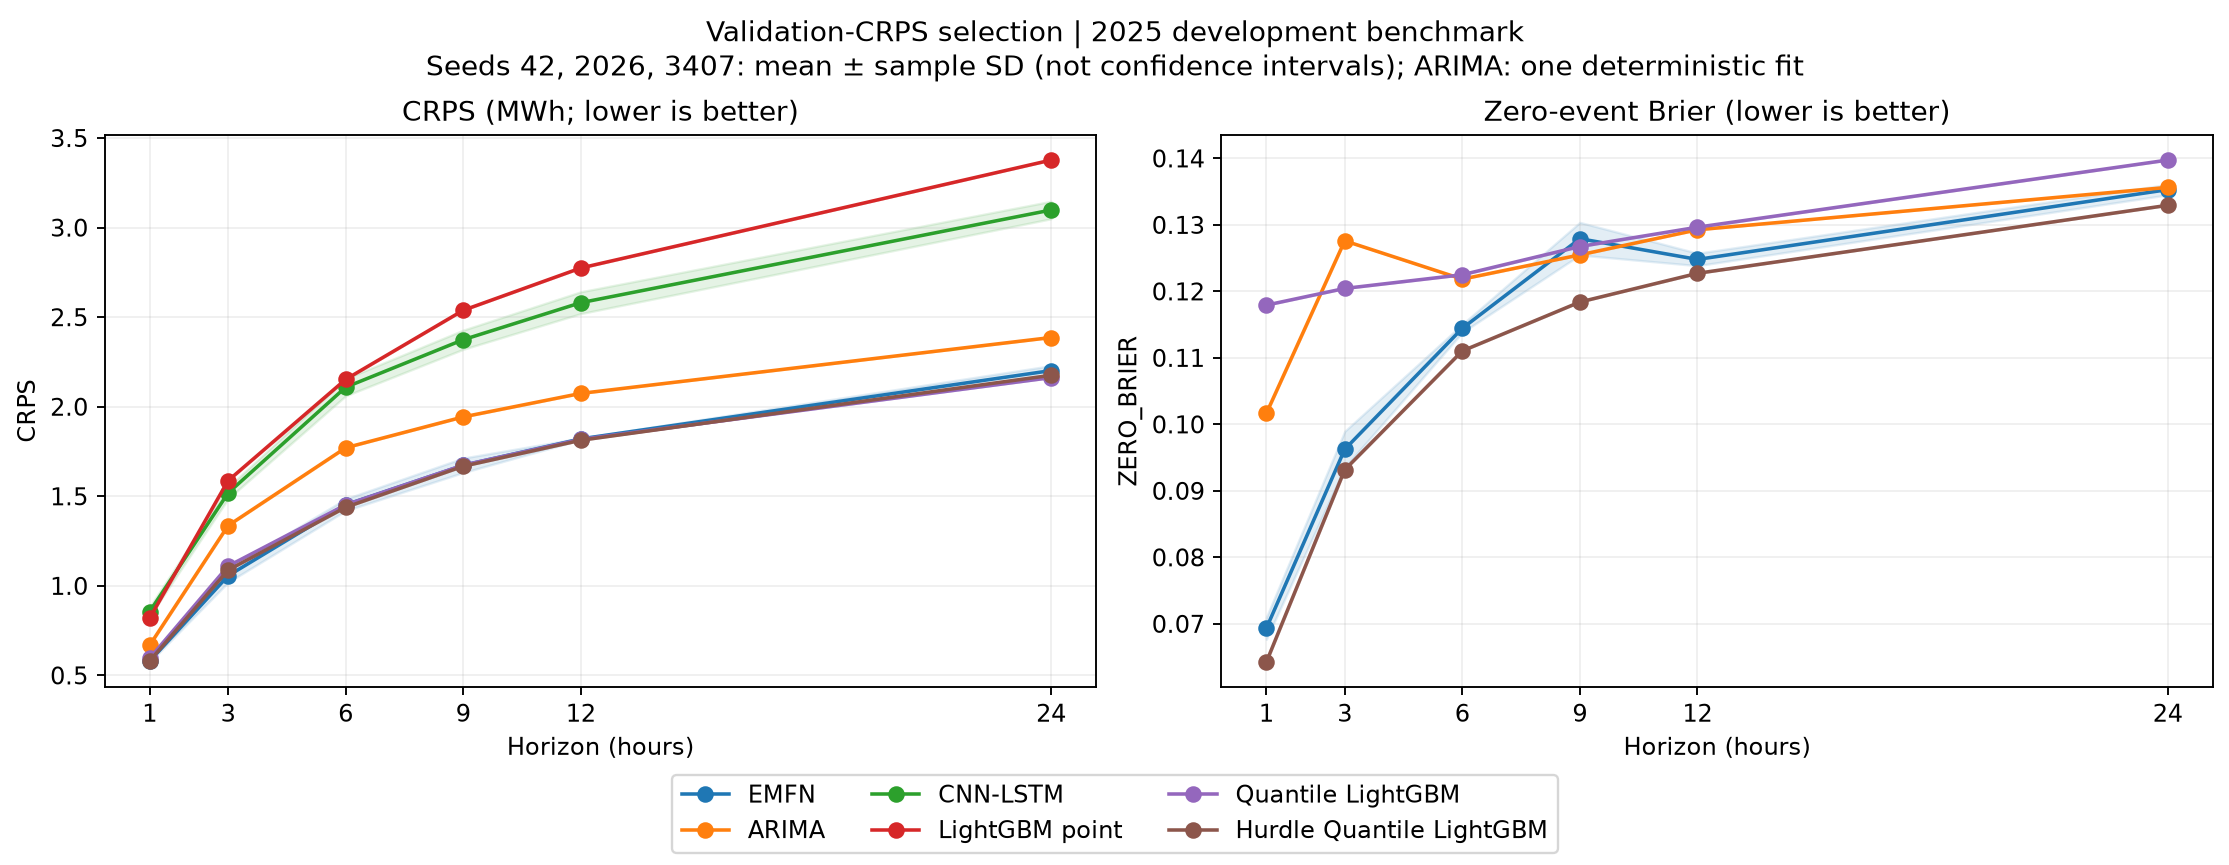

Verified run: crps_multiseed_20261004T175005+0900


In [5]:
multi = json.loads((ROOT/'reports/multiseed_crps_manifest.json').read_text(encoding='utf-8'))
verified = json.loads((ROOT/'reports/multiseed_crps_validation.json').read_text(encoding='utf-8'))
assert multi['status']=='complete' and verified['status']=='passed'
assert multi['run_id']==verified['run_id']
seed_metrics = pd.read_csv(ROOT/'reports/tables/multiseed_crps_metrics.csv')
assert len(seed_metrics)==192
assert seed_metrics.groupby(['split','horizon_hours'])['count'].nunique().eq(1).all()
display(pd.read_csv(ROOT/'reports/tables/multiseed_crps_horizon_mean.csv'))
display(pd.read_csv(ROOT/'reports/tables/multiseed_crps_summary.csv').query("split == 'test'"))
intervals = pd.read_csv(ROOT/'reports/tables/multiseed_crps_paired_intervals.csv')
display(intervals[(intervals.model=='Hurdle Quantile LightGBM (24h matched)') & (intervals.block_hours==168)])
display(Image(filename=str(ROOT/'reports/figures/multiseed_crps_comparison.png')))
print('Verified run:',multi['run_id'])

## 현재 본문·보조 표 배치 (2026-10-05)

표준 모델 중심 본문은 EMFN·ARIMA·CNN-LSTM·일반 LightGBM(24h)으로 구성합니다. 분위수/허들 분위수 비교는 EMFN과 함께 보조 표에 보존합니다. 두 표는 검증된 다중 시드 요약의 행만 추출했고, 결과 확인 후 조정한 편집 구성입니다. 최대 비교군 5개는 상한이며 Persistence는 추가 후보입니다. 요약표의 mae_mean은 중앙값 MAE의 시드 평균입니다. 개별 실행 CSV에서 같은 이름이 분포 평균 MAE를 뜻하는 것과 구분합니다.

In [6]:
presentation = json.loads((ROOT/'reports/paper_presentation_manifest.json').read_text(encoding='utf-8'))
assert presentation['run_id']==multi['run_id']
assert presentation['status']=='verified_subset_only'
main_view=pd.read_csv(ROOT/'reports/tables/paper_main_standard_baselines.csv')
prob_view=pd.read_csv(ROOT/'reports/tables/paper_supplementary_probability.csv')
assert len(main_view)==24 and len(prob_view)==18
print('Main: standard baselines; mean/SD across fitted seeds')
display(main_view)
print('Supplement: probabilistic comparisons; all earlier results retained')
display(prob_view)

Main: standard baselines; mean/SD across fitted seeds


,model,horizon_hours,n_fits,crps_mean,crps_sd,zero_brier_mean,zero_brier_sd,rmse_mean,rmse_sd,mae_mean,mae_sd,zero_auprc_mean,zero_auprc_sd,run_id,selection_basis
0,EMFN (Proposed),1,3,0.580223,0.005759,0.069339,0.001660,1.287867,1.550043e-02,0.800300,0.009938,0.751612,0.002811,crps_multiseed_20261004T175005+0900,validation_crps
1,ARIMA,1,1,0.668857,NaN,0.101655,NaN,1.426100,NaN,0.836900,NaN,0.621272,NaN,crps_multiseed_20261004T175005+0900,validation_crps
2,CNN-LSTM (+Weather),1,3,0.856458,0.026192,NaN,NaN,1.374067,3.809650e-02,0.856467,0.026212,NaN,NaN,crps_multiseed_20261004T175005+0900,validation_crps
3,LightGBM (24h matched),1,3,0.820885,0.000000,NaN,NaN,1.286700,0.000000e+00,0.820900,0.000000,NaN,NaN,crps_multiseed_20261004T175005+0900,validation_crps
4,EMFN (Proposed),3,3,1.056345,0.036286,0.096253,0.002716,2.323767,6.518008e-02,1.474800,0.042226,0.560140,0.011372,crps_multiseed_20261004T175005+0900,validation_crps
5,ARIMA,3,1,1.336205,NaN,0.127608,NaN,2.813400,NaN,1.785300,NaN,0.475515,NaN,crps_multiseed_20261004T175005+0900,validation_crps
6,CNN-LSTM (+Weather),3,3,1.518371,0.031965,NaN,NaN,2.426033,6.631096e-02,1.518367,0.031988,NaN,NaN,crps_multiseed_20261004T175005+0900,validation_crps
7,LightGBM (24h matched),3,3,1.587343,0.000000,NaN,NaN,2.337200,0.000000e+00,1.587300,0.000000,NaN,NaN,crps_multiseed_20261004T175005+0900,validation_crps
8,EMFN (Proposed),6,3,1.452854,0.032934,0.114448,0.000611,3.167767,6.470435e-02,2.023867,0.037780,0.434305,0.004298,crps_multiseed_20261004T175005+0900,validation_crps
9,ARIMA,6,1,1.770985,NaN,0.121843,NaN,3.568300,NaN,2.460800,NaN,0.410169,NaN,crps_multiseed_20261004T175005+0900,validation_crps


Supplement: probabilistic comparisons; all earlier results retained


,model,horizon_hours,n_fits,crps_mean,crps_sd,zero_brier_mean,zero_brier_sd,rmse_mean,rmse_sd,mae_mean,mae_sd,zero_auprc_mean,zero_auprc_sd,run_id,selection_basis
0,EMFN (Proposed),1,3,0.580223,5.758518e-03,0.069339,1.659979e-03,1.287867,1.550043e-02,0.800300,0.009938,0.751612,2.810994e-03,crps_multiseed_20261004T175005+0900,validation_crps
1,Quantile LightGBM (24h matched),1,3,0.596026,0.000000e+00,0.117936,0.000000e+00,1.395000,2.719480e-16,0.805100,0.000000,0.598647,0.000000e+00,crps_multiseed_20261004T175005+0900,validation_crps
2,Hurdle Quantile LightGBM (24h matched),1,3,0.581340,0.000000e+00,0.064250,0.000000e+00,1.348900,2.719480e-16,0.792100,0.000000,0.758524,1.359740e-16,crps_multiseed_20261004T175005+0900,validation_crps
3,EMFN (Proposed),3,3,1.056345,3.628621e-02,0.096253,2.715925e-03,2.323767,6.518008e-02,1.474800,0.042226,0.560140,1.137194e-02,crps_multiseed_20261004T175005+0900,validation_crps
4,Quantile LightGBM (24h matched),3,3,1.110365,0.000000e+00,0.120446,0.000000e+00,2.513100,0.000000e+00,1.497600,0.000000,0.463229,0.000000e+00,crps_multiseed_20261004T175005+0900,validation_crps
5,Hurdle Quantile LightGBM (24h matched),3,3,1.087832,0.000000e+00,0.093175,0.000000e+00,2.444200,0.000000e+00,1.485900,0.000000,0.555360,0.000000e+00,crps_multiseed_20261004T175005+0900,validation_crps
6,EMFN (Proposed),6,3,1.452854,3.293425e-02,0.114448,6.113322e-04,3.167767,6.470435e-02,2.023867,0.037780,0.434305,4.298103e-03,crps_multiseed_20261004T175005+0900,validation_crps
7,Quantile LightGBM (24h matched),6,3,1.452294,0.000000e+00,0.122504,1.699675e-17,3.200900,5.438960e-16,1.982500,0.000000,0.388893,0.000000e+00,crps_multiseed_20261004T175005+0900,validation_crps
8,Hurdle Quantile LightGBM (24h matched),6,3,1.438614,0.000000e+00,0.111045,0.000000e+00,3.154800,0.000000e+00,1.977800,0.000000,0.422723,6.798700e-17,crps_multiseed_20261004T175005+0900,validation_crps
9,EMFN (Proposed),9,3,1.673164,4.041042e-02,0.127927,2.453517e-03,3.566567,7.584361e-02,2.331800,0.046605,0.346858,2.327497e-02,crps_multiseed_20261004T175005+0900,validation_crps
